/var/folders/g9/yz_7j3f54qd48ppbxvt_l0nc0000gn/T/ipykernel_44969/1892108964.py:24: FutureWarning: waveshow() keyword argument 'x_axis' has been renamed to 'axis' in version 0.10.0.
	This alias will be removed in version 1.0.
  librosa.display.waveshow(sig, sr = sr, x_axis='time') # color.


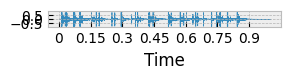

In [10]:
import librosa.display, librosa
import matplotlib.pyplot as plt

#Load file
wav_files = ['test/sample_fireworks.wav']

#Convert sound to numeric values
def librosa_read_wav_files(wav_files):
 return [librosa.load(f)[0] for f in wav_files] # amplitude amplitude

#audio source sr load
wav_rate = librosa.load(wav_files[0])[1] #22050
wav_x = librosa_read_wav_files(wav_files) 

# print(len(wav_x)) #1
# print(wav_x) #[array([2.0720760e-04, 3.3121114e-04, 1.4992662e-04, ..., 9.1752947e-05, 6.1937237e-05, 0.0000000e+00], dtype=float32)]

#graph
widht_height_size = (3,0.2) #(6, 2) ---> (16, 2).
plt.figure(figsize = (widht_height_size))
plt.style.use('bmh') # check? https://hong-yp-ml-records.tistory.com/88

sig, sr = (wav_x[0] ,len(wav_x[0]))
librosa.display.waveshow(sig, sr = sr, x_axis='time') # color.


In [11]:
import matplotlib.pyplot as plt

def draw_probability_bars(pred):
    probs = [float(pred[0][0]), float(pred[0][1])]
    labels = ['firework', 'gunshot']
    colors = ['#aafeff', 'red']

    fig, ax = plt.subplots(figsize=(5.5, 1.4))
    ax.barh(labels, probs, color=colors)
    ax.set_xlim(0, 1)
    ax.set_xlabel('probability')
    plt.tight_layout()
    return fig, ax

In [12]:
# required packages
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import numpy as np
from keras.models import load_model
import librosa
import librosa.display
from pygame import mixer
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.figure import Figure

file_path = ''
x_test_features = None
wave_canvas = None
prob_canvas = None


def resolve_existing_path(*candidates):
    for candidate in candidates:
        candidate_path = Path(candidate)
        if candidate_path.exists():
            return str(candidate_path)
    raise FileNotFoundError(f'File not found. Tried: {candidates}')


# code to load model
model = load_model(resolve_existing_path('./model_keras.h5', 'model_keras.h5'))


# function to extract features from audio
def extract_features(audio_samples, sample_rate):
    extracted_features = np.empty((0, 41), dtype=float)
    if not isinstance(audio_samples, list):
        audio_samples = [audio_samples]

    for sample in audio_samples:
        zero_cross_feat = librosa.feature.zero_crossing_rate(sample).mean()
        mfccs = librosa.feature.mfcc(y=sample, sr=sample_rate, n_mfcc=40)
        mfcc_scaled = np.mean(mfccs.T, axis=0)
        mfcc_scaled = np.append(mfcc_scaled, zero_cross_feat).reshape(1, 41)
        extracted_features = np.vstack((extracted_features, mfcc_scaled))
    return extracted_features


# update status card
def set_status(level, title, message):
    badge_style = {
        'idle': {'text': 'READY', 'bg': '#374151'},
        'safe': {'text': 'SAFE', 'bg': '#065f46'},
        'alert': {'text': 'ALERT', 'bg': '#991b1b'},
    }
    style = badge_style.get(level, badge_style['idle'])
    status_badge.configure(text=style['text'], bg=style['bg'])
    result_title.configure(text=title)
    result_message.configure(text=message)


# upload sound function
def upload_sound():
    global file_path
    global x_test_features

    try:
        selected_path = filedialog.askopenfilename(
            parent=top,
            filetypes=[('Audio files', '*.wav *.mp3 *.ogg'), ('All files', '*.*')]
        )
        if not selected_path:
            return

        file_path = selected_path
        x_test, wave_rate = librosa.load(file_path, sr=None)
        x_test_features = extract_features(x_test, wave_rate)

        file_value.configure(text=Path(file_path).name)
        confidence_value.configure(text='-')
        set_status('idle', 'File loaded', 'Run classification to evaluate risk signal.')

        Wav_graph(file_path)
    except Exception as error:
        set_status('alert', 'Upload error', f'Could not read file: {error}')


# audio graph
def Wav_graph(wav_file):
    global wave_canvas

    signal, sample_rate = librosa.load(wav_file, sr=None)
    figure = Figure(figsize=(7.1, 1.5), facecolor='#111827')
    axes = figure.add_subplot()
    librosa.display.waveshow(signal, sr=sample_rate, axis='time', color='#38bdf8', ax=axes)
    axes.set_facecolor('#111827')
    axes.tick_params(colors='#9ca3af')
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)
    axes.spines['left'].set_color('#374151')
    axes.spines['bottom'].set_color('#374151')
    axes.set_ylabel('amp', color='#9ca3af')
    axes.set_xlabel('time (s)', color='#9ca3af')

    if wave_canvas is not None:
        wave_canvas.get_tk_widget().destroy()

    wave_canvas = FigureCanvasTkAgg(figure, master=right_panel)
    wave_canvas.get_tk_widget().place(x=20, y=38)


# probability graph
def Draw_graph(pred):
    global prob_canvas

    firework_prob = float(pred[0][0])
    gunshot_prob = float(pred[0][1])

    if prob_canvas is not None:
        prob_canvas.get_tk_widget().destroy()

    figure = Figure(figsize=(7.1, 1.5), facecolor='#111827')
    axes = figure.add_subplot()
    labels = ['Firework', 'Gunshot']
    probs = [firework_prob, gunshot_prob]
    colors = ['#f59e0b', '#ef4444']

    axes.barh(labels, probs, color=colors)
    axes.set_xlim([0, 1])
    axes.set_facecolor('#111827')
    axes.set_xlabel('probability', color='#9ca3af')
    axes.tick_params(colors='#d1d5db')
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)
    axes.spines['left'].set_color('#374151')
    axes.spines['bottom'].set_color('#374151')

    prob_canvas = FigureCanvasTkAgg(figure, master=right_panel)
    prob_canvas.get_tk_widget().place(x=20, y=210)


# classify function (audio result output)
def classify():
    if x_test_features is None:
        set_status('idle', 'No file selected', 'Please upload an audio file first.')
        return

    pred = model.predict(x_test_features.reshape(1, 41), verbose=0)
    predicted_index = int(np.argmax(pred))

    firework_prob = float(pred[0][0])
    gunshot_prob = float(pred[0][1])
    confidence = max(firework_prob, gunshot_prob)
    confidence_value.configure(text=f'{confidence * 100:.2f}%')

    if predicted_index == 0:
        set_status('safe', 'Firework pattern detected', 'Low risk signal. Continue passive monitoring.')
    else:
        set_status('alert', 'Possible gunshot detected', 'High risk signal. Check surroundings and verify immediately.')

    Draw_graph(pred)


# audio play / stop functions
def Play():
    if file_path:
        if not mixer.get_init():
            mixer.init()
        mixer.music.load(file_path)
        mixer.music.play()


def Stop():
    if file_path and mixer.get_init():
        mixer.music.stop()


# user interface
top = tk.Tk()
top.geometry('1200x420')
top.title('Safe Alert Audio Monitor')
top.configure(background='#0b1220')
top.resizable(width=0, height=0)

header = tk.Frame(top, bg='#0f172a', height=54, width=1200)
header.place(x=0, y=0)

title_label = tk.Label(
    header,
    text='SAFE ALERT AUDIO MONITOR',
    bg='#0f172a',
    fg='#e5e7eb',
    font=('Arial', 16, 'bold')
)
title_label.place(x=20, y=13)

subtitle_label = tk.Label(
    header,
    text='Classify uploaded sounds into Firework / Gunshot with risk-focused output',
    bg='#0f172a',
    fg='#93c5fd',
    font=('Arial', 9)
)
subtitle_label.place(x=360, y=19)

left_panel = tk.Frame(top, bg='#111827', width=360, height=335)
left_panel.place(x=20, y=70)

right_panel = tk.Frame(top, bg='#111827', width=800, height=335)
right_panel.place(x=390, y=70)

status_badge = tk.Label(
    left_panel,
    text='READY',
    bg='#374151',
    fg='white',
    width=10,
    pady=6,
    font=('Arial', 10, 'bold')
)
status_badge.place(x=20, y=20)

result_title = tk.Label(
    left_panel,
    text='Awaiting input',
    bg='#111827',
    fg='#f3f4f6',
    anchor='w',
    justify='left',
    font=('Arial', 12, 'bold')
)
result_title.place(x=20, y=64)

result_message = tk.Label(
    left_panel,
    text='Upload an audio file to start monitoring.',
    bg='#111827',
    fg='#9ca3af',
    wraplength=315,
    justify='left',
    anchor='w',
    font=('Arial', 10)
)
result_message.place(x=20, y=92)

file_label = tk.Label(left_panel, text='File', bg='#111827', fg='#9ca3af', font=('Arial', 10))
file_label.place(x=20, y=150)
file_value = tk.Label(left_panel, text='-', bg='#111827', fg='#f3f4f6', font=('Arial', 10, 'bold'))
file_value.place(x=90, y=150)

confidence_label = tk.Label(left_panel, text='Confidence', bg='#111827', fg='#9ca3af', font=('Arial', 10))
confidence_label.place(x=20, y=180)
confidence_value = tk.Label(left_panel, text='-', bg='#111827', fg='#f3f4f6', font=('Arial', 10, 'bold'))
confidence_value.place(x=90, y=180)

button_style = {
    'font': ('Arial', 10, 'bold'),
    'fg': '#111827',
    'bd': 0,
    'activeforeground': '#111827',
    'cursor': 'hand2'
}

btn_upload = tk.Button(left_panel, text='Upload Audio', bg='#2563eb', activebackground='#1d4ed8', command=upload_sound, **button_style)
btn_upload.place(x=20, y=245, width=150, height=36)

btn_classify = tk.Button(left_panel, text='Run Classification', bg='#ea580c', activebackground='#c2410c', command=classify, **button_style)
btn_classify.place(x=190, y=245, width=150, height=36)

btn_play = tk.Button(left_panel, text='Play', bg='#10b981', activebackground='#059669', command=Play, **button_style)
btn_play.place(x=20, y=290, width=150, height=30)

btn_stop = tk.Button(left_panel, text='Stop', bg='#ef4444', activebackground='#dc2626', command=Stop, **button_style)
btn_stop.place(x=190, y=290, width=150, height=30)

wave_title = tk.Label(right_panel, text='Waveform', bg='#111827', fg='#e5e7eb', font=('Arial', 11, 'bold'))
wave_title.place(x=20, y=12)

prob_title = tk.Label(right_panel, text='Class Probabilities', bg='#111827', fg='#e5e7eb', font=('Arial', 11, 'bold'))
prob_title.place(x=20, y=184)

footer = tk.Label(
    top,
    text='Model Copyright KSS | UI redesigned for code-based safe-alert monitoring',
    bg='#0b1220',
    fg='#64748b',
    font=('Arial', 8)
)
footer.place(x=760, y=402)

top.mainloop()

KeyboardInterrupt: 